<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
df=pd.read_csv('/content/data.csv').drop(columns=['id','Unnamed: 32'])
df.head()
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],test_size=0.2, random_state=2)
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[-0.04462793, -1.41612656, -0.05903514, ..., -0.18278004,
        -1.23064515, -0.6268286 ],
       [ 0.24583601, -0.06219797,  0.21802678, ...,  0.54129749,
         0.11047691,  0.0483572 ],
       [-1.26115925, -0.29051645, -1.26499659, ..., -1.35138617,
         0.269338  , -0.28231213],
       ...,
       [ 0.72709489,  0.45836817,  0.75277276, ...,  1.46701686,
         1.19909344,  0.65319961],
       [ 0.25437907,  1.33054477,  0.15659489, ..., -1.29043534,
        -2.22561725, -1.59557344],
       [ 0.84100232, -0.06676434,  0.8929529 , ...,  2.15137705,
         0.35629355,  0.37459546]])

1 -> 0.8859649122807017
2 -> 0.8859649122807017
3 -> 0.9035087719298246
4 -> 0.8947368421052632
5 -> 0.9122807017543859
6 -> 0.9210526315789473
7 -> 0.9298245614035088
8 -> 0.9298245614035088
9 -> 0.9298245614035088
10 -> 0.9298245614035088
11 -> 0.9298245614035088
12 -> 0.9298245614035088
13 -> 0.9298245614035088
14 -> 0.9298245614035088
15 -> 0.9298245614035088
16 -> 0.9298245614035088
17 -> 0.9298245614035088
18 -> 0.9298245614035088
19 -> 0.9298245614035088


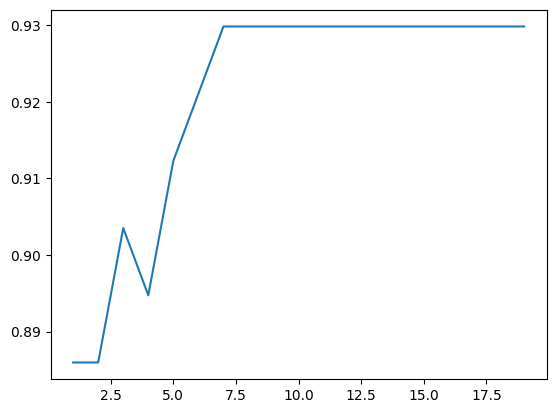

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
op=[]
for i in range(1,20):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred=knn.predict(X_test)
  op.append(accuracy_score(y_test,y_pred))
  print(i,'->',accuracy_score(y_test,y_pred))
  # print(i)
import matplotlib.pyplot as plt

plt.plot(range(1,20),op)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));


interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

R² Score: 0.798447125601065
MSE: 424.0771117773426


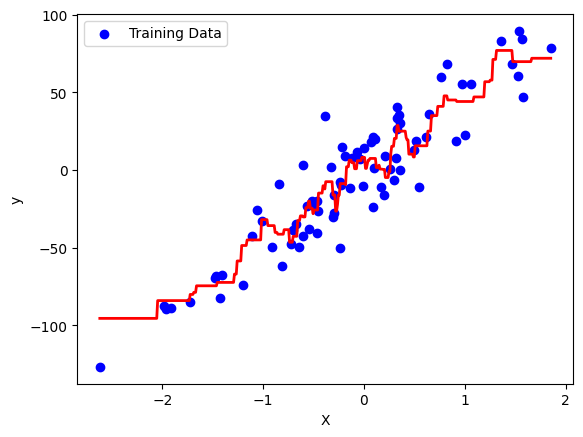

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
knn = KNeighborsRegressor(
    n_neighbors=5,
    # weights='distance'
    algorithm='kd_tree',p=1.0001,leaf_size=100,n_jobs=-1

)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
plt.scatter(X_train, y_train, color='blue', label='Training Data')

X_range = np.linspace(X.min(), X.max(), 500).reshape(-1,1)
y_range = knn.predict(X_range)

plt.plot(X_range, y_range, color='red', linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()